# XAUUSD — Lane Comparison & Performance Monitor

**Purpose:** Offline research notebook. Evaluates BUY and SELL model outputs side-by-side
to measure whether the opposing model adds value as a cross-filter and to backtest the
SELL lane's equity curve.

**This notebook does NOT feed the live pipeline.** Production decisions are made by
`frival/main.py` using only `XAUUSD_H1_sell_Ensemble.joblib` + the agent layer. The CSV
exported in Section 8 is an audit artefact, not a runtime input.

**Production lane:** SELL (live). BUY lane: offline comparison only.

**How the two-lane comparison works:**
- Every H1 bar is scored by both models independently
- BUY fires when `buy_proba ≥ buy_threshold` AND `sell_proba < cross_filter`
- SELL fires when `sell_proba ≥ sell_threshold` AND `buy_proba < cross_filter`
- Both exceed thresholds → **CONFLICT → skip**
- `CROSS_FILTER = 1.0` = disabled; lanes evaluated independently

**Pipeline:**
1. Load both model bundles (buy + sell)
2. Load raw data → compute features
3. Score validation + test sets
4. Compare standalone vs combined precision
5. Vector backtest SELL lane (Section 11)
6. Export lane-comparison CSV (audit only)

---
**Improved version** — `PERFORMANCE_IMPROVEMENT_RECOMMENDATIONS.md`:
- **R11** cooldown dtype fix  · **R10** quality gate  · **R2** fair SELL evaluation
- **R5** expected-value backtest  · **R7** Wilson 95% CI + monthly walk-forward

In [1]:
import sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Python : {sys.version}")


Python : 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:29:43) [MSC v.1943 64 bit (AMD64)]


## 1. Configuration


In [2]:
ROOT      = Path("../..").resolve()
PAIR      = "XAUUSD"
TIMEFRAME = "H1"

# ── Production lane (live in frival/main.py) ──────────────────────────────────
PRODUCTION_LANE = "SELL"   # only this lane is live; BUY is offline comparison only

# ── Model bundles ─────────────────────────────────────────────────────────────
BUY_MODEL_PATH  = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_buy_*.joblib"),  key=lambda p: p.stat().st_mtime, default=None)
SELL_MODEL_PATH = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_sell_*.joblib"), key=lambda p: p.stat().st_mtime, default=None)

if BUY_MODEL_PATH is None or SELL_MODEL_PATH is None:
    raise FileNotFoundError("No .joblib model found in models_bin/")

RAW_FILE  = ROOT / "data" / "raw" / "mt5" / TIMEFRAME / f"{PAIR}_{TIMEFRAME}.csv"

TRAIN_END  = "2025-06-30 23:00:00"
VAL_START  = "2025-07-01 00:00:00"
VAL_END    = "2025-12-31 23:00:00"
TEST_START = "2026-01-01 00:00:00"

# ── Conflict filter ───────────────────────────────────────────────────────────
# 1.0 = disabled; both lanes evaluated independently (no cross-suppression).
CROSS_FILTER = 1.0

COOLDOWN_BARS = 4   # minimum bars between same-direction signals (4 h on H1)

# Both lanes compared here — production runs SELL only (see PRODUCTION_LANE).
BUY_ONLY       = False
SESSION_FILTER = False

print(f"Production lane: {PRODUCTION_LANE}")
print(f"Buy  bundle  : {BUY_MODEL_PATH.name}")
print(f"Sell bundle  : {SELL_MODEL_PATH.name}")
print(f"Raw data     : {RAW_FILE.exists()}")
print(f"Cross-filter : {CROSS_FILTER}  (1.0 = disabled)")
print(f"Cooldown     : {COOLDOWN_BARS} bars")
print(f"BUY-only     : {BUY_ONLY}  (False = both lanes compared)")
print(f"Session filt : {SESSION_FILTER}")

Production lane: SELL
Buy  bundle  : XAUUSD_H1_buy_Ensemble.joblib
Sell bundle  : XAUUSD_H1_sell_Ensemble.joblib
Raw data     : True
Cross-filter : 1.0  (1.0 = disabled)
Cooldown     : 4 bars
BUY-only     : False  (False = both lanes compared)
Session filt : False


## 2. Load Model Bundles


In [3]:
# Each bundle contains: model, features list, threshold, atr params
buy_bundle  = joblib.load(BUY_MODEL_PATH)
sell_bundle = joblib.load(SELL_MODEL_PATH)

BUY_THRESHOLD  = buy_bundle["threshold"]
SELL_THRESHOLD = sell_bundle["threshold"]

print(f"BUY  model threshold : {BUY_THRESHOLD}")
print(f"SELL model threshold : {SELL_THRESHOLD}")
print(f"BUY  features        : {len(buy_bundle['features'])}")
print(f"SELL features        : {len(sell_bundle['features'])}")
print(f"Both use ATR_TP_MULT : {buy_bundle['atr_tp_mult']}  FW: {buy_bundle['forward_bars']} bars")


BUY  model threshold : 0.35
SELL model threshold : 0.341
BUY  features        : 31
SELL features        : 20
Both use ATR_TP_MULT : 1.5  FW: 6 bars


## 3. Load Data & Compute Features

We reuse the same `compute_features()` function from the training notebooks.
Both models were trained on the same full feature set — they just selected different subsets.


In [4]:
ATR_PERIOD = buy_bundle["atr_tp_mult"]   # for the feature function — both use 14
ATR_PERIOD = 14   # override: both models were built with ATR_PERIOD=14

df_raw = pd.read_csv(RAW_FILE, parse_dates=["datetime"])
df_raw = df_raw.sort_values("datetime").reset_index(drop=True)
print(f"Rows: {len(df_raw):,}  |  {df_raw['datetime'].min()} → {df_raw['datetime'].max()}")


Rows: 45,077  |  2019-01-02 01:00:00 → 2026-08-17 16:00:00


In [5]:
def merge_aux_symbols(df, pair=None):
    """Merge daily context from auxiliary macro symbols (WTI / USDX).

    Resamples the auxiliary symbol's H1 close to daily, derives momentum + trend
    features, shifts 1 day (so H1 bars see only yesterday's values - no lookahead),
    then merges on calendar date. Missing values are forward-filled; any rows still
    lacking aux data (early warm-up) are dropped.

    Pair mapping:
      XAUUSD -> USDX  (US dollar index - gold's dominant inverse driver)
      USDCAD -> WTI   (WTI crude - CAD's dominant driver) + USDX
    """
    mapping = {
        "XAUUSD": ["USDX"],
        "USDCAD": ["WTI", "USDX"],
    }
    symbols = mapping.get(pair or "", [])
    if not symbols:
        return df

    df = df.copy()
    for sym in symbols:
        alias = "dxy" if sym == "USDX" else "wti"
        aux_path = ROOT / "data" / "raw" / "mt5" / TIMEFRAME / f"{sym}_H1.csv"
        if not aux_path.exists():
            print(f"  ! {sym}_H1.csv not found - skipping {alias} features")
            continue

        a = pd.read_csv(aux_path, parse_dates=["datetime"]).sort_values("datetime")
        daily = a.set_index("datetime")[["close"]].resample("1D").last().dropna()

        daily[f"{alias}_ema20"] = daily["close"].ewm(span=20, adjust=False).mean()
        daily[f"{alias}_ema50"] = daily["close"].ewm(span=50, adjust=False).mean()
        daily[f"{alias}_ret_1d"] = daily["close"].pct_change(1)
        daily[f"{alias}_ret_5d"] = daily["close"].pct_change(5)
        daily[f"{alias}_vs_ema20"] = (daily["close"] - daily[f"{alias}_ema20"]) / daily["close"]
        daily[f"{alias}_trend"] = (daily[f"{alias}_ema20"] > daily[f"{alias}_ema50"]).astype(int)

        feat_cols = [f"{alias}_ret_1d", f"{alias}_ret_5d",
                     f"{alias}_vs_ema20", f"{alias}_trend"]
        shifted = daily[feat_cols].shift(1).reset_index().rename(columns={"datetime": "_aux_date"})

        df["_aux_date"] = df["datetime"].dt.normalize()
        df = df.merge(shifted, on="_aux_date", how="left")
        df.drop(columns=["_aux_date"], inplace=True)
        df[feat_cols] = df[feat_cols].ffill()
        print(f"  + merged {len(feat_cols)} {alias} features from {sym}")

    aux_cols = [c for c in df.columns if c.startswith(("dxy_", "wti_"))]
    n_before = len(df)
    df.dropna(subset=aux_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  aux merge: dropped {n_before - len(df):,} warm-up rows, {len(df):,} remain")
    return df


print("merge_aux_symbols() ready")


merge_aux_symbols() ready


In [6]:
def compute_features(data: pd.DataFrame, pair: str = None) -> pd.DataFrame:
    """
    Identical to the function in the training notebooks.
    Computes all H1 technical + D1 context + intraday features.
    """
    df = data.copy()

    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"]       = df["datetime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)

    df["body_size"]  = abs(df["close"] - df["open"])
    df["price_range"]= df["high"] - df["low"]
    df["upper_wick"] = df["high"] - df[["open","close"]].max(axis=1)
    df["lower_wick"] = df[["open","close"]].min(axis=1) - df["low"]
    df["body_ratio"] = df["body_size"] / df["price_range"].replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()
    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()
    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    delta = df["close"].diff()
    gain  = delta.clip(lower=0);  loss = (-delta).clip(lower=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean().replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    low14  = df["low"].rolling(14).min();  high14 = df["high"].rolling(14).max()
    df["stoch_k"]    = 100*(df["close"]-low14)/(high14-low14).replace(0,np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100*(high14-df["close"])/(high14-low14).replace(0,np.nan)
    e12 = df["close"].ewm(span=12,adjust=False).mean()
    e26 = df["close"].ewm(span=26,adjust=False).mean()
    df["macd"]            = e12 - e26
    df["macd_sig"]        = df["macd"].ewm(span=9,adjust=False).mean()
    df["macd_hist"]       = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    hl  = df["high"] - df["low"]
    hpc = (df["high"] - df["close"].shift()).abs()
    lpc = (df["low"]  - df["close"].shift()).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    df["atr_14"]    = tr.rolling(ATR_PERIOD).mean()
    df["atr_regime"]= df["atr_14"] / df["atr_14"].rolling(50).mean()
    bm = df["close"].rolling(20).mean();  bs = df["close"].rolling(20).std()
    df["bb_upper"] = bm + 2*bs;  df["bb_lower"] = bm - 2*bs
    df["bb_width"] = (df["bb_upper"]-df["bb_lower"])/bm
    df["bb_pct"]   = (df["close"]-df["bb_lower"])/(df["bb_upper"]-df["bb_lower"]).replace(0,np.nan)
    for w in [10,20,50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = tr.rolling(14).mean()
    pdi  = 100*(plus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    mdi  = 100*(minus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    dx   = 100*(pdi-mdi).abs()/(pdi+mdi).replace(0,np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = pdi;  df["minus_di"] = mdi
    tp = (df["high"]+df["low"]+df["close"])/3
    df["cci_20"]      = (tp-tp.rolling(20).mean())/(0.015*tp.rolling(20).std())
    df["roc_10"]      = df["close"].pct_change(10)*100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    df["obv"]          = (np.sign(df["close"].diff())*df["volume"]).fillna(0).cumsum()
    df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean().replace(0,np.nan)

    # OBV slope/zscore -- stationary replacements for raw OBV
    obv_vals = df["obv"].values
    df["obv_slope_20"] = np.nan
    for i in range(20, len(obv_vals)):
        slope, _ = np.polyfit(range(20), obv_vals[i-20:i], 1)
        df.iloc[i, df.columns.get_loc("obv_slope_20")] = slope
    df["obv_zscore_100"] = (df["obv"] - df["obv"].rolling(100).mean()) / df["obv"].rolling(100).std()

    for lag in [1,2,3,5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)
    for p in [1,5,10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # D1 context
    _d1 = (df.set_index("datetime")[["open","high","low","close","volume"]]
           .resample("1D").agg({"open":"first","high":"max","low":"min","close":"last","volume":"sum"})
           .dropna())
    _d1["d1_ema20"] = _d1["close"].ewm(span=20,adjust=False).mean()
    _d1["d1_ema50"] = _d1["close"].ewm(span=50,adjust=False).mean()
    _d1["d1_trend"] = (_d1["d1_ema20"]>_d1["d1_ema50"]).astype(int)
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]   = 100 - 100/(1+_dd.clip(lower=0).rolling(14).mean()
                                  /(-_dd).clip(lower=0).rolling(14).mean().replace(0,np.nan))
    _d1["d1_close_vs_ema20"] = (_d1["close"]-_d1["d1_ema20"])/_d1["close"]
    _d1s = (_d1[["d1_ema20","d1_ema50","d1_trend","d1_rsi","d1_close_vs_ema20"]]
            .shift(1).reset_index().rename(columns={"datetime":"_d1_date"}))

    df["_date"]  = df["datetime"].dt.normalize()
    _do          = df.groupby("_date")["open"].first().rename("_day_open")
    df           = df.join(_do, on="_date")
    df["close_vs_day_open"] = (df["close"]-df["_day_open"])/df["_day_open"]
    df = df.merge(_d1s, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date","_d1_date","_day_open"], inplace=True)

    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows after warm-up: {len(df):,}  (dropped {n_before-len(df)})")

    # Calendar features (optional -- no lookahead)
    if pair:
        try:
            import sys
            from pathlib import Path as _Path
            _root = _Path('../../..').resolve()
            if str(_root / 'frival') not in sys.path:
                sys.path.insert(0, str(_root / 'frival'))
            from data.calendar import compute_calendar_features
            cal_feats = compute_calendar_features(df["datetime"], pair)
            for col in cal_feats.columns:
                df[col] = cal_feats[col].values
            print(f"Calendar features merged: {list(cal_feats.columns)}")
        except Exception as e:
            print(f"Calendar features skipped: {e}")

    return df

df_features = compute_features(df_raw, pair=PAIR)
df_features = merge_aux_symbols(df_features, PAIR)
print(f"Feature matrix: {df_features.shape}")


Rows after warm-up: 44,723  (dropped 354)
[calendar] Loaded 39,164 events for XAUUSD (2007-02-13 -> 2026-12-31)
  HIGH: 4,084  MED+: 19,047  Dev loaded: 17,639
Calendar features merged: ['high_events_next_1h', 'med_events_next_1h', 'high_events_next_4h', 'med_events_next_4h', 'high_events_next_24h', 'med_events_next_24h', 'any_event_next_1h', 'deviation_sum_24h', 'hours_since_last_high', 'is_fomc_day', 'is_ecb_day', 'is_boe_day', 'is_snb_day', 'is_nfp_day']
  + merged 4 dxy features from USDX
  aux merge: dropped 0 warm-up rows, 44,723 remain
Feature matrix: (44723, 102)


## 4. Score Both Models on Validation + Test


In [7]:
def score_split(df_feat: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    """
    Slice a date range from df_features, run both models, return a combined dataframe.
    Each row has: datetime, close, buy_proba, sell_proba.
    """
    mask = (df_feat["datetime"] >= start) & (df_feat["datetime"] <= end)
    df   = df_feat[mask].copy().reset_index(drop=True)

    # Score with each model using its own feature subset
    X_buy  = df[buy_bundle["features"]].fillna(0)
    X_sell = df[sell_bundle["features"]].fillna(0)

    buy_proba  = buy_bundle["model"].predict_proba(X_buy)[:, 1]
    sell_proba = sell_bundle["model"].predict_proba(X_sell)[:, 1]

    session_cols = ["session_london", "session_ny"]
    result = df[["datetime", "close"] + session_cols].copy()
    result["buy_proba"]  = buy_proba
    result["sell_proba"] = sell_proba
    return result


# Score validation and test sets
val_scores  = score_split(df_features, VAL_START, VAL_END)
test_scores = score_split(df_features, TEST_START, "2099-12-31")

print(f"Validation bars : {len(val_scores):,}")
print(f"Test bars       : {len(test_scores):,}")
val_scores.head(3)


Validation bars : 2,999
Test bars       : 3,677


,datetime,close,session_london,session_ny,buy_proba,sell_proba
0,2025-07-01 01:00:00,3311.41,0,0,0.457734,0.240726
1,2025-07-01 02:00:00,3312.44,0,0,0.457734,0.253567
2,2025-07-01 03:00:00,3314.71,0,0,0.456222,0.280920


## 5. Apply Conflict Filter → Combined Signals


In [8]:
def apply_conflict_filter(scores: pd.DataFrame,
                          buy_thr: float, sell_thr: float,
                          cross_filter: float,
                          buy_only: bool = False,
                          session_filter: bool = False,
                          quality_max: float = None) -> pd.DataFrame:
    """
    Apply decision logic to a dataframe of buy_proba / sell_proba.

    Decision rules:
      - When buy_only=True: SELL lane disabled entirely; only BUY signals fire.
      - When session_filter=True: signals gated to London+NY sessions only.
      - CONFLICT   : buy_proba >= buy_thr  AND sell_proba >= sell_thr  -> no trade
      - BUY signal : buy_proba >= buy_thr  AND sell_proba <  cross_filter
      - SELL signal: sell_proba >= sell_thr AND buy_proba  <  cross_filter
      - DO NOTHING : everything else
    """
    df = scores.copy()

    buy_candidate = df["buy_proba"] >= buy_thr

    if not buy_only:
        sell_candidate = df["sell_proba"] >= sell_thr
        df["conflict"] = (buy_candidate & sell_candidate).astype(int)
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = (sell_candidate & (df["buy_proba"] < cross_filter)).astype(int)
        df.loc[df["conflict"] == 1, ["buy_signal", "sell_signal"]] = 0
    else:
        df["conflict"] = 0
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = 0

    # R10: optional same-direction quality gate. Repurposes the (otherwise inert)
    # cross-filter as a confidence booster: keep a signal only when the OPPOSING
    # model is quiet (its probability below `quality_max`). None = disabled.
    if quality_max is not None:
        df["buy_signal"]  = (df["buy_signal"]  & (df["sell_proba"] < quality_max)).astype(int)
        df["sell_signal"] = (df["sell_signal"] & (df["buy_proba"]  < quality_max)).astype(int)

    # Session filter: suppress signals outside London/NY
    if session_filter:
        in_session = (df["session_london"] == 1) | (df["session_ny"] == 1)
        df["buy_signal"]  = df["buy_signal"]  & in_session
        df["sell_signal"] = df["sell_signal"] & in_session

    df["direction"] = "neutral"
    df.loc[df["buy_signal"] == 1, "direction"] = "buy"
    if not buy_only:
        df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    df.loc[df["conflict"] == 1, "direction"] = "conflict"

    return df


def apply_cooldown(df: pd.DataFrame, cooldown_bars: int) -> pd.DataFrame:
    """
    Suppress consecutive same-direction signals within `cooldown_bars` bars.
    Only the FIRST signal in each cluster is kept — avoids entering the same
    trade multiple times in the same market condition.
    BUY and SELL have independent cooldown timers.
    """
    if cooldown_bars == 0:
        return df

    df = df.copy().reset_index(drop=True)
    df["buy_signal"]  = df["buy_signal"].astype(int)   # R11: avoid dtype FutureWarning
    df["sell_signal"] = df["sell_signal"].astype(int)
    last_buy  = -cooldown_bars - 1
    last_sell = -cooldown_bars - 1

    for i in range(len(df)):
        if df.at[i, "buy_signal"] == 1:
            if (i - last_buy) <= cooldown_bars:
                df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
            else:
                last_buy = i
        if df.at[i, "sell_signal"] == 1:
            if (i - last_sell) <= cooldown_bars:
                df.at[i, "sell_signal"] = 0  # too close to previous SELL -> suppress
            else:
                last_sell = i

    # Rebuild direction after suppression
    df["direction"] = "neutral"
    df.loc[df["buy_signal"]  == 1, "direction"] = "buy"
    df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    if "conflict" in df.columns:            # standalone SELL frames (R2) carry no conflict col
        df.loc[df["conflict"] == 1, "direction"] = "conflict"
    return df


# Apply conflict filter + cooldown to validation set
val_combined = apply_conflict_filter(
    val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
val_combined = apply_cooldown(val_combined, COOLDOWN_BARS)

trading_days = len(val_combined) / 24
print(f"=== Validation set  ({len(val_combined):,} bars | {trading_days:.0f} trading days) ===")
print(f"BUY  signals  (standalone candidates)   : {(val_combined['buy_proba']  >= BUY_THRESHOLD).sum()}")
print(f"SELL signals  (standalone candidates)   : {(val_combined['sell_proba'] >= SELL_THRESHOLD).sum()}")
print(f"Conflicts suppressed                     : {val_combined['conflict'].sum()}")
print(f"BUY  after filter + cooldown             : {val_combined['buy_signal'].sum()}  ({val_combined['buy_signal'].sum()/trading_days:.2f}/day)")
print(f"SELL after filter + cooldown             : {val_combined['sell_signal'].sum()}  ({val_combined['sell_signal'].sum()/trading_days:.2f}/day)")
print(f"Total actionable signals                 : {(val_combined['buy_signal'] + val_combined['sell_signal']).sum()}")


=== Validation set  (2,999 bars | 125 trading days) ===
BUY  signals  (standalone candidates)   : 2972
SELL signals  (standalone candidates)   : 52
Conflicts suppressed                     : 52
BUY  after filter + cooldown             : 592  (4.74/day)
SELL after filter + cooldown             : 0  (0.00/day)
Total actionable signals                 : 592


## 6. Evaluate — Standalone vs Combined Precision

We need the true labels to measure precision. We generate them here from the raw data.


In [9]:
def generate_labels(df_feat, forward_bars, atr_tp_mult, atr_sl_mult, direction="buy"):
    """Generate buy (long) or sell (short) binary labels on df_features."""
    close = df_feat["close"].values
    high  = df_feat["high"].values
    low   = df_feat["low"].values
    atr   = df_feat["atr_14"].values
    n     = len(df_feat)
    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        if direction == "buy":
            tp = close[i] + atr[i] * atr_tp_mult
            sl = close[i] - atr[i] * atr_sl_mult
        else:
            tp = close[i] - atr[i] * atr_tp_mult
            sl = close[i] + atr[i] * atr_sl_mult

        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = (low[k] <= tp) if direction == "sell" else (high[k] >= tp)
            sl_hit = (high[k] >= sl) if direction == "sell" else (low[k]  <= sl)
            if tp_hit and sl_hit: result = 0; break
            elif tp_hit:          result = 1; break
            elif sl_hit:          result = 0; break
        labels[i] = result

    return labels


ATR_TP = buy_bundle["atr_tp_mult"]
ATR_SL = buy_bundle["atr_sl_mult"]
FW     = buy_bundle["forward_bars"]

# Generate true labels on the full feature set (same approach as training notebooks)
buy_labels_full  = generate_labels(df_features, FW, ATR_TP, ATR_SL, "buy")
sell_labels_full = generate_labels(df_features, FW, ATR_TP, ATR_SL, "sell")

# Attach to feature dataframe
df_features["buy_label"]  = buy_labels_full
df_features["sell_label"] = sell_labels_full
df_features.dropna(subset=["buy_label","sell_label"], inplace=True)
df_features.reset_index(drop=True, inplace=True)
print(f"Labels computed.  Buy rate: {df_features['buy_label'].mean()*100:.1f}%  "
      f"Sell rate: {df_features['sell_label'].mean()*100:.1f}%")


Labels computed.  Buy rate: 26.4%  Sell rate: 25.1%


In [10]:
# Re-score with labels attached
val_scores  = score_split(df_features, VAL_START, VAL_END)
val_scores["buy_label"]  = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "buy_label"].values
val_scores["sell_label"] = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "sell_label"].values

# Build three views: standalone / filter only / filter + cooldown
val_standalone  = val_scores.copy()
val_standalone["buy_signal"]  = (val_standalone["buy_proba"]  >= BUY_THRESHOLD).astype(int)
val_standalone["sell_signal"] = (val_standalone["sell_proba"] >= SELL_THRESHOLD).astype(int)

val_filtered  = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
val_final     = apply_cooldown(val_filtered.copy(), COOLDOWN_BARS)

# Re-apply conflict column so val_final reflects it
val_combined = val_final.copy()


def precision(signals, labels):
    fired = signals == 1
    if fired.sum() == 0:
        return float("nan"), 0
    return round(float(labels[fired].mean()), 3), int(fired.sum())


breakeven = ATR_SL / (ATR_TP + ATR_SL)
td = len(val_scores) / 24

print(f"Breakeven precision : {breakeven:.3f}")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(val_standalone["buy_signal"],  val_standalone["buy_label"])
print(f"{'BUY  standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["buy_signal"],   val_filtered["buy_label"])
print(f"{'BUY  + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["buy_signal"],      val_final["buy_label"])
print(f"{'BUY  + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

p, n = precision(val_standalone["sell_signal"],  val_standalone["sell_label"])
print(f"{'SELL standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["sell_signal"],   val_filtered["sell_label"])
print(f"{'SELL + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["sell_signal"],      val_final["sell_label"])
print(f"{'SELL + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

# Combined final precision
total = int(val_final["buy_signal"].sum() + val_final["sell_signal"].sum())
correct = int(
    ((val_final["buy_signal"]  == 1) & (val_final["buy_label"]  == 1) |
     (val_final["sell_signal"] == 1) & (val_final["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td:>7.2f}")


Breakeven precision : 0.400

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  standalone                     0.309       2972    23.78
BUY  + cross-filter                 0.309       2920    23.37
BUY  + filter + cooldown            0.306        592     4.74

SELL standalone                     0.481         52     0.42
SELL + cross-filter                   nan          0     0.00
SELL + filter + cooldown              nan          0     0.00

COMBINED final                      0.306        592     4.74


In [11]:
# ── Cross-filter sweep ────────────────────────────────────────────────────────
# Shows precision and signal count for BUY and SELL at every candidate
# cross-filter value. Helps you pick the right CROSS_FILTER.
#
# Key reference points:
#   1.0         = no cross-filter (same as standalone)
#   SELL_THRESHOLD = suppress BUY only when SELL would actually fire
#   0.60        = suppress BUY if sell_proba looks genuinely elevated
#   base rate   ≈ 0.25 — don't go below this

sweep_values = [1.0, SELL_THRESHOLD, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40]

print(f"{'Cross-filter':>13}  {'BUY prec':>9}  {'BUY n':>7}  {'BUY/day':>8}  "
      f"{'SELL prec':>10}  {'SELL n':>7}  {'SELL/day':>9}")
print("-" * 80)

for cf in sweep_values:
    tmp = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    pb, nb = precision(tmp["buy_signal"],  tmp["buy_label"])
    ps, ns = precision(tmp["sell_signal"], tmp["sell_label"])
    marker = " ← current" if cf == CROSS_FILTER else ""
    pb_s = f"{pb:.3f}" if not np.isnan(pb) else "  nan"
    ps_s = f"{ps:.3f}" if not np.isnan(ps) else "  nan"
    print(f"{cf:>13.3f}  {pb_s:>9}  {nb:>7}  {nb/td:>8.2f}  "
          f"{ps_s:>10}  {ns:>7}  {ns/td:>9.2f}{marker}")

print(f"\nBreakeven : {breakeven:.3f}")
print(f"Hint: choose the highest cross-filter where BUY precision ≥ {breakeven:.3f}")


 Cross-filter   BUY prec    BUY n   BUY/day   SELL prec   SELL n   SELL/day
--------------------------------------------------------------------------------
        1.000      0.309     2920     23.37         nan        0       0.00 ← current
        0.341      0.309     2920     23.37         nan        0       0.00
        0.700      0.309     2920     23.37         nan        0       0.00
        0.650      0.309     2920     23.37         nan        0       0.00
        0.600      0.309     2920     23.37         nan        0       0.00
        0.550      0.309     2920     23.37         nan        0       0.00
        0.500      0.309     2920     23.37         nan        0       0.00
        0.450      0.309     2920     23.37         nan        0       0.00
        0.400      0.309     2920     23.37         nan        0       0.00

Breakeven : 0.400
Hint: choose the highest cross-filter where BUY precision ≥ 0.400


## 7. Visualization — Signal Map & Cross-Filter Effect


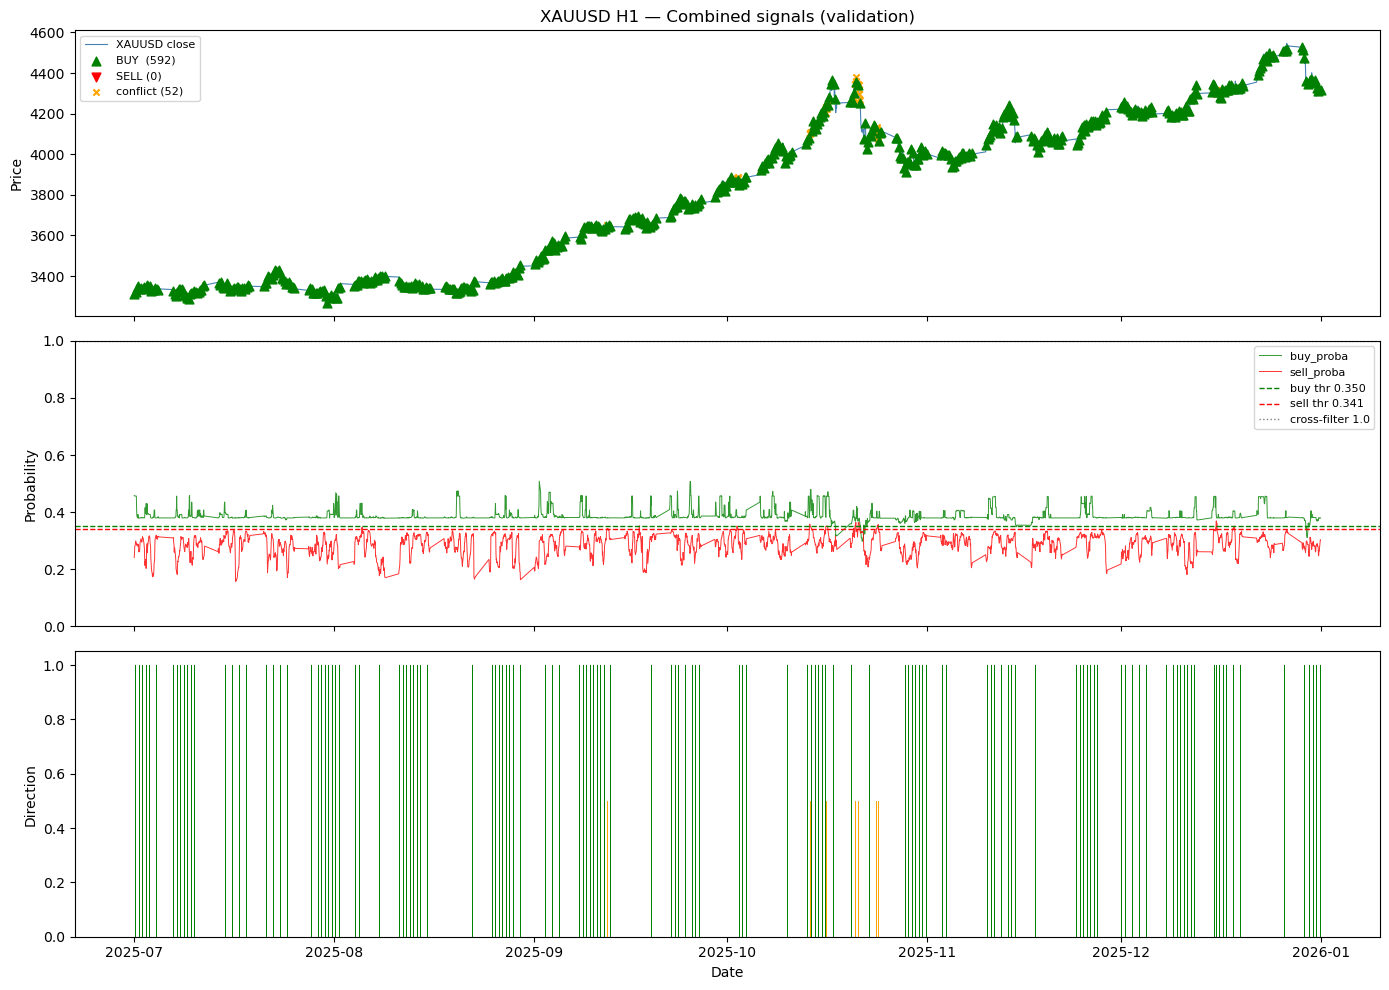

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = val_combined["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, val_combined["close"], color="steelblue", lw=0.8, label="XAUUSD close")
buy_bars  = val_combined[val_combined["buy_signal"]  == 1]
sell_bars = val_combined[val_combined["sell_signal"] == 1]
conf_bars = val_combined[val_combined["conflict"]    == 1]
ax.scatter(buy_bars["datetime"],  buy_bars["close"],  marker="^", color="green",  s=40, zorder=5, label=f"BUY  ({len(buy_bars)})")
ax.scatter(sell_bars["datetime"], sell_bars["close"], marker="v", color="red",    s=40, zorder=5, label=f"SELL ({len(sell_bars)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} — Combined signals (validation)")
ax.legend(fontsize=8)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, val_combined["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, val_combined["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
direction_map = {"neutral": 0, "buy": 1, "sell": -1, "conflict": 0.5}
ax = axes[2]
colors = val_combined["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, val_combined["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


## 8. Export — Lane Comparison CSV (Audit Artefact)

Exports test-set signal decisions for offline inspection. **Not read by the live pipeline** — `frival/main.py` scores signals in real-time and writes its own JSONL to `frival/output/signals/`.

In [13]:
test_combined = apply_conflict_filter(
    test_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
test_combined = apply_cooldown(test_combined, COOLDOWN_BARS)

td_test = len(test_combined) / 24

print(f"=== Test set ({len(test_combined):,} bars | {td_test:.0f} trading days) ===")
print(f"BUY  signals : {test_combined['buy_signal'].sum()}  ({test_combined['buy_signal'].sum()/td_test:.2f}/day)")
print(f"SELL signals : {test_combined['sell_signal'].sum()}  ({test_combined['sell_signal'].sum()/td_test:.2f}/day)")
print(f"Conflicts    : {test_combined['conflict'].sum()}")

OUTPUT_DIR = ROOT / "data" / "signals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUTPUT_DIR / f"{PAIR}_{TIMEFRAME}_lane_comparison_test.csv"
test_combined.to_csv(out_path, index=False)
print(f"\n✓ Saved (audit only, not read by live pipeline) → {out_path}")

display(test_combined[test_combined["direction"] != "neutral"].head(30))


=== Test set (3,677 bars | 153 trading days) ===
BUY  signals : 714  (4.66/day)
SELL signals : 0  (0.00/day)
Conflicts    : 75

✓ Saved (audit only, not read by live pipeline) → C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\signals\XAUUSD_H1_lane_comparison_test.csv


,datetime,close,session_london,session_ny,buy_proba,sell_proba,conflict,buy_signal,sell_signal,direction
0,2026-01-02 01:00:00,4348.26,0,0,0.380634,0.285955,0,1,0,buy
5,2026-01-02 06:00:00,4373.19,0,0,0.380984,0.318367,0,1,0,buy
10,2026-01-02 11:00:00,4385.48,1,0,0.415298,0.317953,0,1,0,buy
15,2026-01-02 16:00:00,4353.41,0,1,0.396494,0.317962,0,1,0,buy
17,2026-01-02 18:00:00,4326.51,0,1,0.373816,0.342208,1,0,0,conflict
18,2026-01-02 19:00:00,4323.05,0,1,0.373174,0.342094,1,0,0,conflict
19,2026-01-02 20:00:00,4315.11,0,1,0.373174,0.343519,1,0,0,conflict
20,2026-01-02 21:00:00,4318.08,0,1,0.373174,0.336970,0,1,0,buy
25,2026-01-05 03:00:00,4401.79,0,0,0.375722,0.257326,0,1,0,buy
30,2026-01-05 08:00:00,4420.28,1,0,0.419414,0.272478,0,1,0,buy


## 9. Test Set Evaluation — Sealed Hold-Out

The test set (2026-02-02 → 2026-07-03) is the final arbiter. We evaluate precision
on this untouched window to detect overfitting. Validation results are useful for
calibration, but **test results determine whether the strategy is production-ready**.


In [14]:
# Merge labels into test_combined
test_with_labels = test_combined.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_with_labels.reset_index(drop=True, inplace=True)

td_test = len(test_with_labels) / 24

# Validation reference (val_combined already has labels from Section 6)
p_val_buy,  n_val_buy  = precision(val_combined["buy_signal"],  val_combined["buy_label"])
p_val_sell, n_val_sell = precision(val_combined["sell_signal"], val_combined["sell_label"])
total_val = n_val_buy + n_val_sell
correct_val = int(
    ((val_combined["buy_signal"]  == 1) & (val_combined["buy_label"]  == 1) |
     (val_combined["sell_signal"] == 1) & (val_combined["sell_label"] == 1)).sum()
)
p_val = round(correct_val / total_val, 3) if total_val > 0 else float("nan")
td_val = len(val_combined) / 24

print(f"=== Test Set ({len(test_with_labels):,} bars | {td_test:.0f} trading days) ===")
print(f"Breakeven precision: {breakeven:.3f}  (R:R = 1:{ATR_TP/ATR_SL})")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(test_with_labels["buy_signal"], test_with_labels["buy_label"])
print(f"{'BUY  final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

p, n = precision(test_with_labels["sell_signal"], test_with_labels["sell_label"])
print(f"{'SELL final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

total = int(test_with_labels["buy_signal"].sum() + test_with_labels["sell_signal"].sum())
correct = int(
    ((test_with_labels["buy_signal"]  == 1) & (test_with_labels["buy_label"]  == 1) |
     (test_with_labels["sell_signal"] == 1) & (test_with_labels["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print()
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")

print(f"\n=== Overfit Check ===")
print(f"{'Val  COMBINED':<30} {p_val:>10.3f}  {total_val:>9}  {total_val/td_val:>7.2f}")
print(f"{'Test COMBINED':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")
print(f"{'Gap (val - test)':<30} {p_val-p_combined:>+10.3f}")
print(f"{'Overfit?':<30} {'YES - gap > 0.05' if p_val-p_combined > 0.05 else 'Acceptable'}")


=== Test Set (3,671 bars | 153 trading days) ===
Breakeven precision: 0.400  (R:R = 1:1.5)

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  final                          0.258        713     4.66
SELL final                            nan          0     0.00

COMBINED final                      0.258        713     4.66

=== Overfit Check ===
Val  COMBINED                       0.306        592     4.74
Test COMBINED                       0.258        713     4.66
Gap (val - test)                   +0.048
Overfit?                       Acceptable


In [15]:
# Cross-filter sweep on test set
test_scores_with_labels = test_scores.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_scores_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_scores_with_labels.reset_index(drop=True, inplace=True)

print(f"Cross-filter sweep on test set ({len(test_scores_with_labels):,} bars)")
print()
print(f"{'CF':>6}  {'BUY prec':>9}  {'BUY n':>6}  {'/day':>6}  {'SELL prec':>10}  {'SELL n':>7}  {'/day':>6}  {'COMB prec':>10}  {'COMB n':>7}  {'/day':>6}")
print("-" * 95)

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = apply_conflict_filter(test_scores_with_labels, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p_b, n_b = precision(tmp["buy_signal"], tmp["buy_label"])
    p_s, n_s = precision(tmp["sell_signal"], tmp["sell_label"])
    total_n = n_b + n_s
    correct_n = int(
        ((tmp["buy_signal"]  == 1) & (tmp["buy_label"]  == 1) |
         (tmp["sell_signal"] == 1) & (tmp["sell_label"] == 1)).sum()
    )
    p_c = round(correct_n / total_n, 3) if total_n > 0 else float("nan")

    b_mark = "" if (p_b or 0) >= breakeven else " *"
    s_mark = "" if (p_s or 0) >= breakeven else " *"
    c_mark = "" if (p_c or 0) >= breakeven else " *"
    sel = " <--" if cf == CROSS_FILTER else ""

    print(f"{cf:>5.2f}{sel:<4}  {p_b or 0:>8.3f}{b_mark:<2}  {n_b:>6}  {n_b/td_test:>5.2f}  {p_s or 0:>9.3f}{s_mark:<2}  {n_s:>7}  {n_s/td_test:>5.2f}  {p_c or 0:>9.3f}{c_mark:<2}  {total_n:>7}  {total_n/td_test:>5.2f}")

print()
print(f"* = below breakeven ({breakeven:.3f})")
print(f"Selected CROSS_FILTER = {CROSS_FILTER} (from validation calibration)")


Cross-filter sweep on test set (3,671 bars)

    CF   BUY prec   BUY n    /day   SELL prec   SELL n    /day   COMB prec   COMB n    /day
-----------------------------------------------------------------------------------------------
 0.80         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.75         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.70         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.65         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.60         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.55         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.50         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.45         0.258 *     713   4.66        nan *        0   0.00      0.258 *      713   4.66
 0.40  

### 9.1 Side-by-Side: BUY+SELL vs BUY-only

Does the SELL lane add value, or is a BUY-only strategy equivalent?
We compare the combined dual-model approach against using only the BUY model
at various cross-filter strengths.


In [16]:
print(f"{'Strategy':<40} {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 70)

# BUY+SELL combined (current approach)
print(f"{'BUY+SELL combined (cf=' + str(CROSS_FILTER) + ')':<40} {p_combined:>9.3f}  {total:>7}  {total/td_test:>6.2f}")

# BUY-only: no cross-filter, just threshold + cooldown
test_buy_only = test_scores_with_labels.copy()
test_buy_only["buy_signal"] = (test_buy_only["buy_proba"] >= BUY_THRESHOLD).astype(int)
test_buy_only["sell_signal"] = 0
test_buy_only["conflict"] = 0
test_buy_only["direction"] = "neutral"
test_buy_only.loc[test_buy_only["buy_signal"] == 1, "direction"] = "buy"
test_buy_only = apply_cooldown(test_buy_only, COOLDOWN_BARS)
p_bo, n_bo = precision(test_buy_only["buy_signal"], test_buy_only["buy_label"])
print(f"{'BUY-only (no cross-filter)':<40} {p_bo:>9.3f}  {n_bo:>7}  {n_bo/td_test:>6.2f}")

print()

# BUY-only with cross-filter sweep
print(f"{'BUY-only cf':>12}  {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 40)

best_cf = None
best_prec = 0

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = test_scores_with_labels.copy()
    tmp["buy_signal"] = (
        (tmp["buy_proba"] >= BUY_THRESHOLD) &
        (tmp["sell_proba"] < cf)
    ).astype(int)
    tmp["sell_signal"] = 0
    tmp["conflict"] = 0
    tmp["direction"] = "neutral"
    tmp.loc[tmp["buy_signal"] == 1, "direction"] = "buy"
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p, n = precision(tmp["buy_signal"], tmp["buy_label"])
    mark = " <-- best" if p and p > best_prec else ""
    if p and p > best_prec:
        best_prec = p
        best_cf = cf
    be_mark = "  ABOVE breakeven" if (p or 0) >= breakeven else ""
    print(f"{cf:>11.2f}  {p or 0:>9.3f}  {n:>7}  {n/td_test:>6.2f}{mark}{be_mark}")

print(f"\nBreakeven: {breakeven:.3f}")
if best_cf is not None:
    print(f"BUY-only best: cf={best_cf:.2f}  prec={best_prec:.3f}")
else:
    print("BUY-only: never crosses breakeven with any cross-filter")


Strategy                                 Precision  Signals    /day
----------------------------------------------------------------------
BUY+SELL combined (cf=1.0)                   0.258      713    4.66
BUY-only (no cross-filter)                   0.259      723    4.73

 BUY-only cf  Precision  Signals    /day
----------------------------------------
       0.80      0.259      723    4.73 <-- best
       0.75      0.259      723    4.73
       0.70      0.259      723    4.73
       0.65      0.259      723    4.73
       0.60      0.259      723    4.73
       0.55      0.259      723    4.73
       0.50      0.259      723    4.73
       0.45      0.259      723    4.73
       0.40      0.259      723    4.73
       0.35      0.257      720    4.71
       0.30      0.269      561    3.67 <-- best

Breakeven: 0.400
BUY-only best: cf=0.30  prec=0.269


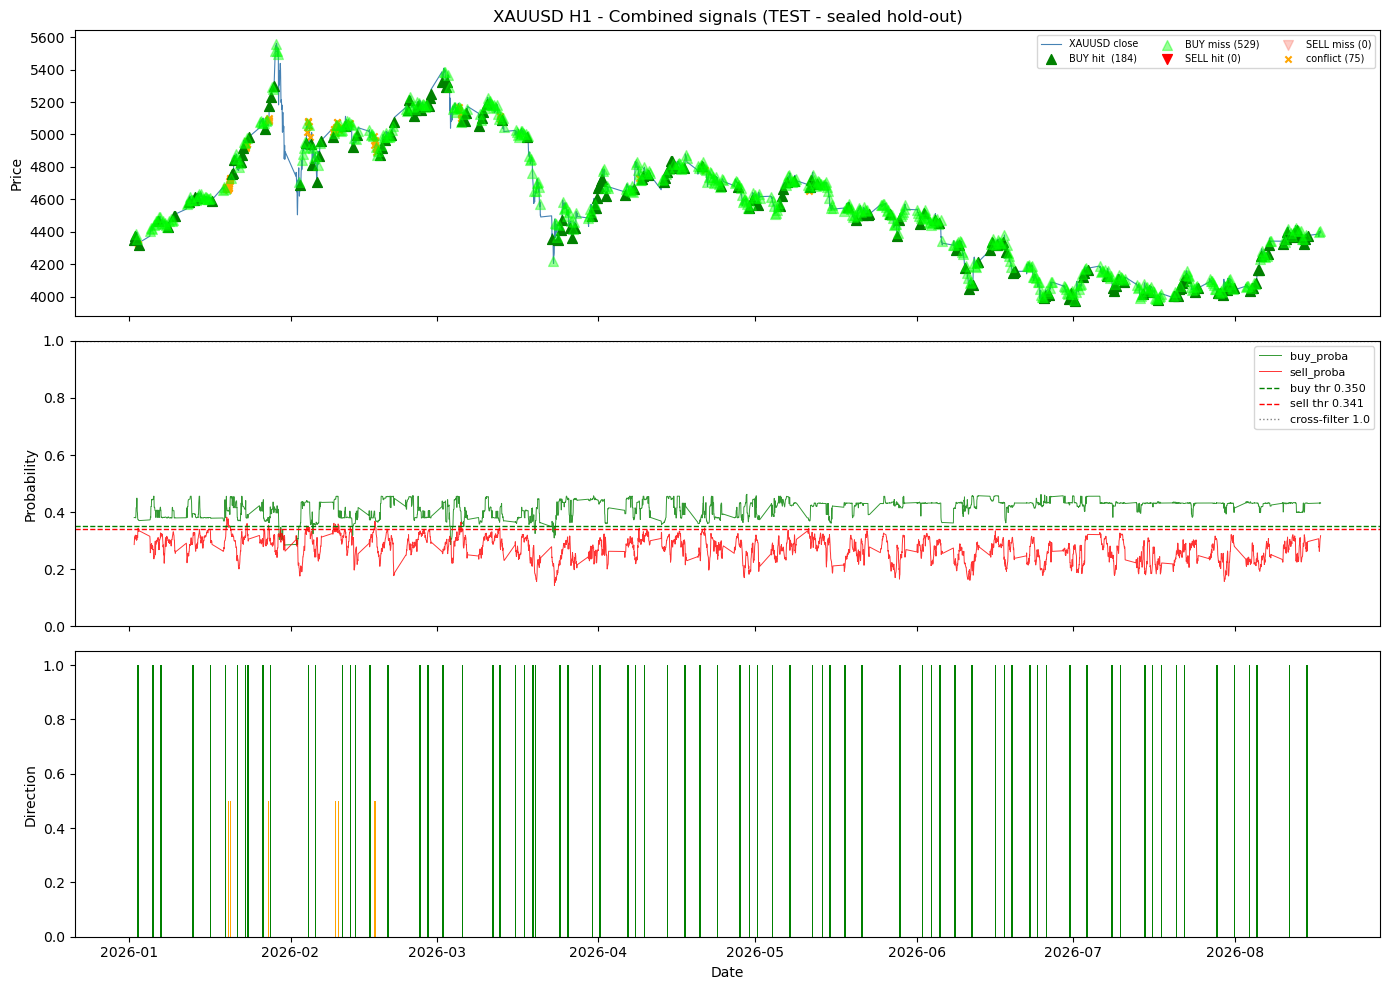

Test period: 2026-01-02 to 2026-08-17
Total signals: 713  |  Hits: 184  |  Precision: 0.258


In [17]:
# Test set visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = test_with_labels["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, test_with_labels["close"], color="steelblue", lw=0.8, label="XAUUSD close")
buy_bars  = test_with_labels[test_with_labels["buy_signal"]  == 1]
sell_bars = test_with_labels[test_with_labels["sell_signal"] == 1]
conf_bars = test_with_labels[test_with_labels["conflict"]    == 1]

buy_hits  = buy_bars[buy_bars["buy_label"] == 1]
buy_miss  = buy_bars[buy_bars["buy_label"] == 0]
sell_hits = sell_bars[sell_bars["sell_label"] == 1]
sell_miss = sell_bars[sell_bars["sell_label"] == 0]

ax.scatter(buy_hits["datetime"],  buy_hits["close"],  marker="^", color="green",  s=50, zorder=5, label=f"BUY hit  ({len(buy_hits)})")
ax.scatter(buy_miss["datetime"],  buy_miss["close"],  marker="^", color="lime",   s=50, zorder=5, alpha=0.4, label=f"BUY miss ({len(buy_miss)})")
ax.scatter(sell_hits["datetime"], sell_hits["close"], marker="v", color="red",    s=50, zorder=5, label=f"SELL hit ({len(sell_hits)})")
ax.scatter(sell_miss["datetime"], sell_miss["close"], marker="v", color="salmon",  s=50, zorder=5, alpha=0.4, label=f"SELL miss ({len(sell_miss)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} - Combined signals (TEST - sealed hold-out)")
ax.legend(fontsize=7, ncol=3)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, test_with_labels["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, test_with_labels["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
ax = axes[2]
colors = test_with_labels["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, test_with_labels["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"Test period: {dates.min().strftime('%Y-%m-%d')} to {dates.max().strftime('%Y-%m-%d')}")
print(f"Total signals: {total}  |  Hits: {correct}  |  Precision: {p_combined}")


## 10. Improved Evaluation — EV, Confidence Intervals & SELL Lane

Adds the guardrails from the recommendations document:
- **R5** expected value in R-units and net pips (precision alone hides EV-negative streams)
- **R7** Wilson 95% confidence intervals + monthly walk-forward stability
- **R2** a fair sealed-test evaluation of the SELL lane (never suppressed by `BUY_ONLY`)


In [18]:
# ── R5 / R7 helpers ───────────────────────────────────────────────────────────
SPREAD_PIPS = 25   # XAUUSD typical round-trip spread assumption (cents (1 pip = $0.01))
PIP         = 0.01

# Per-signal ATR lets us express each outcome in risk (R) units net of spread.
_atr = df_features[["datetime", "atr_14"]]


def wilson_ci(k, n, z=1.96):
    """Wilson score 95% interval for a binomial proportion (precision)."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom  = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half   = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def evaluate_ev(sig_df, signal_col, label_col, tp_mult, sl_mult,
                spread_pips=SPREAD_PIPS, pip=PIP):
    """R5: expected value in R-units and net pips for the fired signals."""
    fired = sig_df[sig_df[signal_col] == 1].merge(_atr, on="datetime", how="left")
    n = len(fired)
    if n == 0:
        return {"n": 0}
    wins    = (fired[label_col] == 1).values
    gross_R = np.where(wins, tp_mult / sl_mult, -1.0)          # 1R = SL distance
    spread_R = (spread_pips * pip) / (fired["atr_14"].values * sl_mult)
    net_R   = gross_R - spread_R
    gross_pips = np.where(wins, tp_mult * fired["atr_14"].values / pip,
                                -sl_mult * fired["atr_14"].values / pip)
    net_pips = gross_pips - spread_pips
    k = int(wins.sum())
    lo, hi = wilson_ci(k, n)
    return {
        "n": n, "hits": k, "precision": round(k / n, 3),
        "prec_ci95": (round(float(lo), 3), round(float(hi), 3)),
        "EV_R": round(float(net_R.mean()), 4),
        "total_R": round(float(net_R.sum()), 2),
        "EV_pips": round(float(net_pips.mean()), 2),
        "total_pips": round(float(net_pips.sum()), 1),
    }


print("✓ wilson_ci() and evaluate_ev() ready")
print(f"Spread assumption: {SPREAD_PIPS} pips | Breakeven precision: {breakeven:.3f}")


✓ wilson_ci() and evaluate_ev() ready
Spread assumption: 25 pips | Breakeven precision: 0.400


In [19]:
# ── R5 / R7: expected value + confidence interval on the sealed test set ─────
print("=== Test set — expected value & 95% confidence intervals ===\n")
for lane, sig_col, lab_col in [("BUY", "buy_signal", "buy_label"),
                               ("SELL", "sell_signal", "sell_label")]:
    r = evaluate_ev(test_with_labels, sig_col, lab_col, ATR_TP, ATR_SL)
    if r["n"] == 0:
        print(f"{lane:4s}: no signals in the main (gated) pipeline")
        continue
    print(f"{lane:4s}: n={r['n']:3d}  prec={r['precision']:.3f}  CI95={r['prec_ci95']}  "
          f"EV={r['EV_R']:+.3f}R ({r['EV_pips']:+.2f} pips)  "
          f"total={r['total_R']:+.1f}R ({r['total_pips']:+.0f} pips)")

print("\nRead: EV > 0 means the lane is profitable after spread.")
print("If the precision CI straddles breakeven, the sample is too small to conclude.")


=== Test set — expected value & 95% confidence intervals ===

BUY : n=713  prec=0.258  CI95=(0.227, 0.291)  EV=-0.367R (-869.18 pips)  total=-261.9R (-619727 pips)
SELL: no signals in the main (gated) pipeline

Read: EV > 0 means the lane is profitable after spread.
If the precision CI straddles breakeven, the sample is too small to conclude.


In [20]:
# ── R2: fair sealed-test evaluation of the SELL lane ─────────────────────────
# The SELL model was disabled by BUY_ONLY in the main pipeline. Here we evaluate
# it on its own threshold with NO cross-filter and NO BUY_ONLY suppression — the
# clean test it never received — both raw and with session+cooldown gating.
sell_raw = test_scores_with_labels.copy()
sell_raw["buy_signal"]  = 0
sell_raw["sell_signal"] = (sell_raw["sell_proba"] >= SELL_THRESHOLD).astype(int)
r_raw = evaluate_ev(sell_raw, "sell_signal", "sell_label", ATR_TP, ATR_SL)

sell_gated = sell_raw.copy()
if SESSION_FILTER:
    in_sess = (sell_gated["session_london"] == 1) | (sell_gated["session_ny"] == 1)
    sell_gated["sell_signal"] = (sell_gated["sell_signal"] & in_sess).astype(int)
sell_gated = apply_cooldown(sell_gated, COOLDOWN_BARS)
r_gate = evaluate_ev(sell_gated, "sell_signal", "sell_label", ATR_TP, ATR_SL)

print("=== SELL lane — sealed test, standalone (R2) ===")
print(f"Threshold {SELL_THRESHOLD} | breakeven {breakeven:.3f} | spread {SPREAD_PIPS} pips\n")
for tag, r in [("raw (no gates)      ", r_raw), ("session + cooldown  ", r_gate)]:
    if r["n"] == 0:
        print(f"{tag}: no signals")
        continue
    print(f"{tag}: n={r['n']:3d}  prec={r['precision']:.3f}  CI95={r['prec_ci95']}  "
          f"EV={r['EV_R']:+.3f}R  total={r['total_R']:+.1f}R")
print("\nDecision: adopt the SELL lane only if EV > 0 with a CI that clears breakeven.")


=== SELL lane — sealed test, standalone (R2) ===
Threshold 0.341 | breakeven 0.400 | spread 25 pips

raw (no gates)      : n= 75  prec=0.240  CI95=(0.158, 0.348)  EV=-0.413R  total=-31.0R
session + cooldown  : n= 25  prec=0.200  CI95=(0.089, 0.391)  EV=-0.512R  total=-12.8R

Decision: adopt the SELL lane only if EV > 0 with a CI that clears breakeven.


In [21]:
# ── R7: precision stability across monthly walk-forward folds ────────────────
# One 67-day test window is too small to trust. Splitting the whole post-train
# period into monthly folds shows whether BUY precision is stable or a lucky
# artifact. Uses the raw threshold (ungated) to measure the ranker itself.
val_lab = val_scores.copy()   # already carries buy_label/sell_label from Section 6
_cols = ["datetime", "buy_proba", "sell_proba", "buy_label", "sell_label"]
post = pd.concat([val_lab[_cols], test_scores_with_labels[_cols]], ignore_index=True)
post["month"] = post["datetime"].dt.to_period("M").astype(str)

print(f"=== BUY precision by month (raw threshold {BUY_THRESHOLD:.3f}) ===")
print(f"{'month':<9} {'n':>4} {'hits':>5} {'prec':>6}  {'CI95':>14}")
pooled_k = pooled_n = 0
for m, g in post.groupby("month"):
    fired = g[g["buy_proba"] >= BUY_THRESHOLD]
    n = len(fired); k = int((fired["buy_label"] == 1).sum())
    pooled_k += k; pooled_n += n
    if n == 0:
        continue
    lo, hi = wilson_ci(k, n)
    print(f"{m:<9} {n:>4} {k:>5} {k/n:>6.3f}  [{lo:.2f}, {hi:.2f}]")

lo, hi = wilson_ci(pooled_k, pooled_n)
pooled_prec = pooled_k / max(pooled_n, 1)
print(f"\nPOOLED BUY : n={pooled_n} hits={pooled_k} prec={pooled_prec:.3f} CI95=[{lo:.2f}, {hi:.2f}]")
print(f"Breakeven {breakeven:.3f} — if the pooled CI includes breakeven, the edge is unproven.")


=== BUY precision by month (raw threshold 0.350) ===
month        n  hits   prec            CI95
2025-07    525   145  0.276  [0.24, 0.32]
2025-08    483   133  0.275  [0.24, 0.32]
2025-09    503   169  0.336  [0.30, 0.38]
2025-10    511   168  0.329  [0.29, 0.37]
2025-11    454   162  0.357  [0.31, 0.40]
2025-12    496   142  0.286  [0.25, 0.33]
2026-01    453   145  0.320  [0.28, 0.36]
2026-02    432   119  0.275  [0.24, 0.32]
2026-03    474   100  0.211  [0.18, 0.25]
2026-04    483   120  0.248  [0.21, 0.29]
2026-05    476   110  0.231  [0.20, 0.27]
2026-06    502   125  0.249  [0.21, 0.29]
2026-07    525   145  0.276  [0.24, 0.32]
2026-08    240    90  0.375  [0.32, 0.44]

POOLED BUY : n=6557 hits=1873 prec=0.286 CI95=[0.27, 0.30]
Breakeven 0.400 — if the pooled CI includes breakeven, the edge is unproven.


## 11. Vector Backtesting — Cumulative P&L & Equity Curve

Simulates each SELL signal as a trade with real entry/TP/SL outcomes.
Reports cumulative R, max drawdown, rolling Sharpe, and a trade-by-trade log.


In [22]:
# Vector backtest: simulate every SELL signal on the sealed test set
import matplotlib.ticker as mticker

def vector_backtest(sig_df, atr_tp, atr_sl, forward_bars, spread_pips=25, pip=0.01):
    fired = sig_df[sig_df["sell_signal"] == 1].copy().reset_index(drop=True)
    if len(fired) == 0:
        print("No SELL signals to backtest.")
        return None, None

    close_all = df_features[["datetime", "close", "high", "low", "atr_14"]].copy()
    close_all = close_all.sort_values("datetime").reset_index(drop=True)
    n_all = len(close_all)

    outcomes = []
    for _, row in fired.iterrows():
        sig_dt  = row["datetime"]
        entry   = row["close"]
        atr_val = row.get("atr_14", np.nan)

        pos = close_all[close_all["datetime"] == sig_dt].index
        if len(pos) == 0:
            continue
        i = pos[0]

        if np.isnan(atr_val):
            atr_val = close_all["atr_14"].iloc[i]

        tp_price = entry - atr_val * atr_tp
        sl_price = entry + atr_val * atr_sl
        spread_R = (spread_pips * pip) / (atr_val * atr_sl)

        result = "no_hit"; exit_price = entry
        for j in range(i + 1, min(i + forward_bars + 1, n_all)):
            high_j = close_all["high"].iloc[j]
            low_j  = close_all["low"].iloc[j]
            if low_j <= tp_price and high_j >= sl_price:
                break
            elif low_j <= tp_price:
                result = "tp"; exit_price = tp_price; break
            elif high_j >= sl_price:
                result = "sl"; exit_price = sl_price; break

        gross_R = (atr_tp / atr_sl) if result == "tp" else (-1.0 if result == "sl" else 0.0)
        net_R   = gross_R - spread_R
        outcomes.append({"datetime": sig_dt, "entry": entry, "exit": exit_price,
                         "atr": atr_val, "outcome": result,
                         "gross_R": round(gross_R, 4), "spread_R": round(spread_R, 4),
                         "net_R": round(net_R, 4)})

    trades = pd.DataFrame(outcomes)
    trades["cumulative_R"] = trades["net_R"].cumsum()
    trades["peak_R"]       = trades["cumulative_R"].cummax()
    trades["drawdown_R"]   = trades["cumulative_R"] - trades["peak_R"]
    dd_pct = (trades["drawdown_R"] / trades["peak_R"].replace(0, np.nan)).fillna(0)
    trades["drawdown_pct"] = np.clip(dd_pct, -1, 0)

    wins    = trades[trades["outcome"] == "tp"]
    losses  = trades[trades["outcome"] == "sl"]
    no_hits = trades[trades["outcome"] == "no_hit"]
    wr      = round(len(wins) / max(len(trades), 1), 3)
    avg_R   = round(trades["net_R"].mean(), 4)
    total_R = round(trades["net_R"].sum(), 2)
    max_dd  = round(trades["drawdown_R"].min(), 2)
    sharpe  = round(avg_R / trades["net_R"].std(), 2) if trades["net_R"].std() > 0 else 0.0

    print(f"=== SELL vector backtest (test set, {atr_tp}:{atr_sl} R:R, {spread_pips} pip spread) ===")
    print(f"Trades       : {len(trades)}")
    print(f"  TP hits    : {len(wins)}")
    print(f"  SL hits    : {len(losses)}")
    print(f"  No hit     : {len(no_hits)}")
    print(f"Win rate     : {wr:.3f}")
    print(f"Avg R/trade  : {avg_R:+.3f}R")
    print(f"Total R      : {total_R:+.1f}R")
    print(f"Max drawdown : {max_dd:+.1f}R")
    print(f"Sharpe       : {sharpe}")

    return trades, {"total_R": total_R, "max_dd_R": max_dd, "win_rate": wr,
                    "avg_R": avg_R, "n_trades": len(trades), "sharpe": sharpe}


# Run vector backtest on SELL-only signals (no cross-filter, no session filter)
sell_only_test = test_scores_with_labels.copy()
sell_only_test["sell_signal"] = (sell_only_test["sell_proba"] >= SELL_THRESHOLD).astype(int)
sell_only_test["buy_signal"]  = 0
sell_only_test["conflict"]    = 0
sell_only_test["direction"]   = "neutral"
sell_only_test.loc[sell_only_test["sell_signal"] == 1, "direction"] = "sell"

if SESSION_FILTER:
    in_sess = (sell_only_test["session_london"] == 1) | (sell_only_test["session_ny"] == 1)
    sell_only_test["sell_signal"] = (sell_only_test["sell_signal"] & in_sess).astype(int)

sell_only_test = apply_cooldown(sell_only_test, COOLDOWN_BARS)
sell_only_test = sell_only_test.merge(df_features[["datetime", "atr_14"]], on="datetime", how="left")

trades, bt_summary = vector_backtest(sell_only_test, ATR_TP, ATR_SL, FW)


=== SELL vector backtest (test set, 1.5:1.0 R:R, 25 pip spread) ===
Trades       : 25
  TP hits    : 5
  SL hits    : 16
  No hit     : 4
Win rate     : 0.200
Avg R/trade  : -0.352R
Total R      : -8.8R
Max drawdown : -8.7R
Sharpe       : -0.35


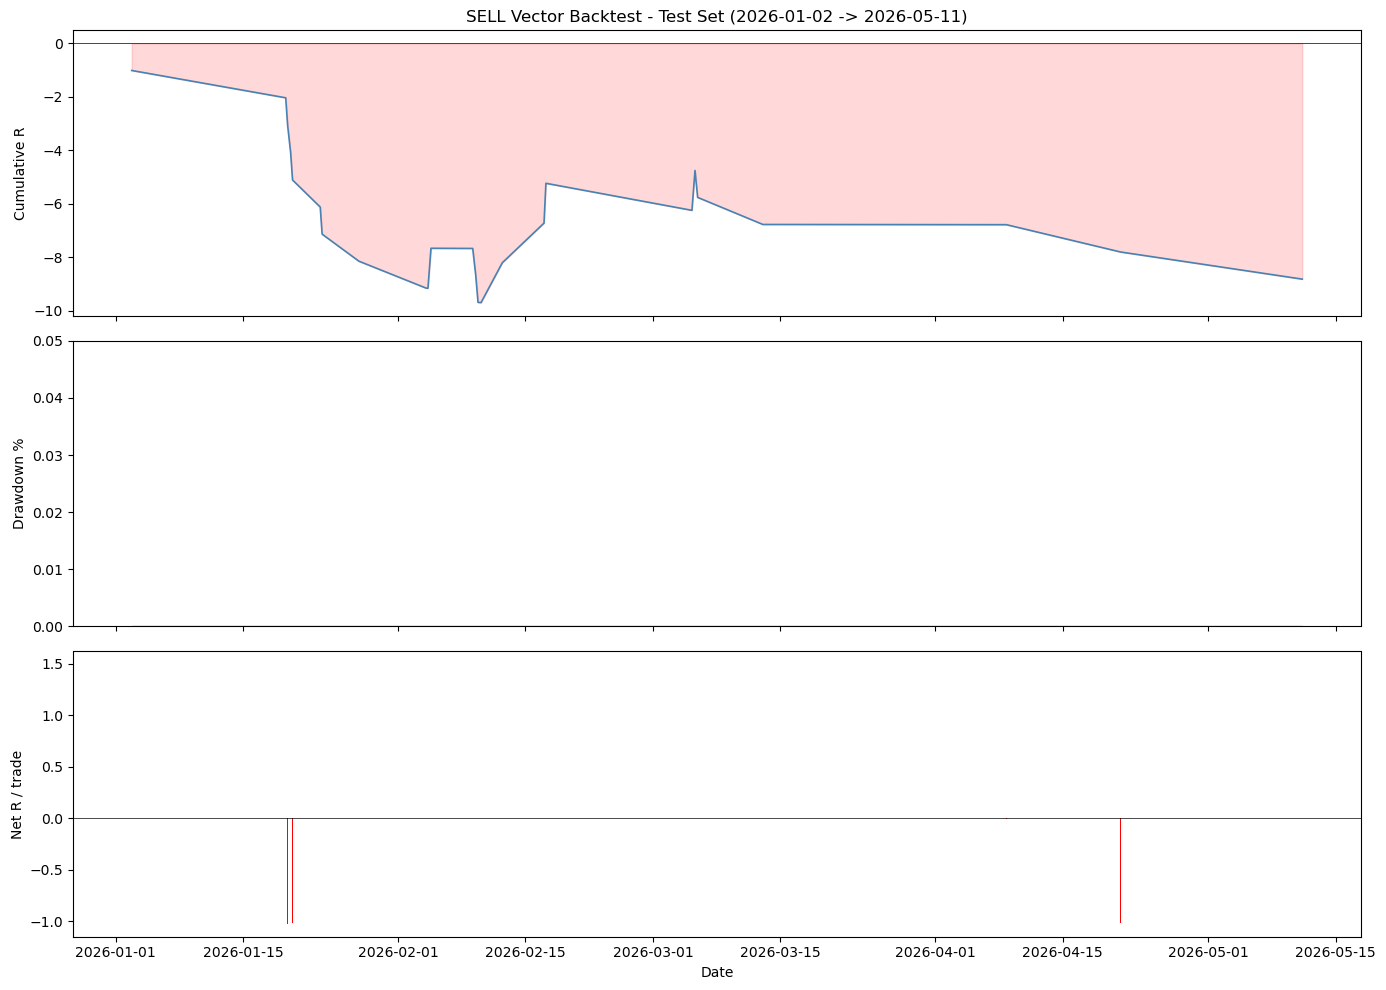


Max drawdown : -8.7R
Sharpe       : -0.35
Total trades : 25

=== Monthly breakdown ===
         trades  total_R  avg_R    wr
month                                
2026-01       8   -8.141 -1.018  0.00
2026-02      10    2.911  0.291  0.40
2026-03       4   -1.538 -0.385  0.25
2026-04       2   -1.028 -0.514  0.00
2026-05       1   -1.014 -1.014  0.00


In [23]:
# Equity curve + drawdown charts
if trades is not None and len(trades) > 1:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(trades["datetime"], trades["cumulative_R"], color="steelblue", lw=1.2)
    ax.fill_between(trades["datetime"], 0, trades["cumulative_R"],
                    where=trades["cumulative_R"] >= 0, color="green", alpha=0.15)
    ax.fill_between(trades["datetime"], 0, trades["cumulative_R"],
                    where=trades["cumulative_R"] < 0, color="red", alpha=0.15)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Cumulative R")
    t0 = trades["datetime"].min().strftime("%Y-%m-%d")
    t1 = trades["datetime"].max().strftime("%Y-%m-%d")
    ax.set_title(f"SELL Vector Backtest - Test Set ({t0} -> {t1})")

    ax = axes[1]
    ax.fill_between(trades["datetime"], 0, trades["drawdown_pct"], color="red", alpha=0.3)
    ax.set_ylabel("Drawdown %")
    ax.set_ylim(trades["drawdown_pct"].min() * 1.1, 0.05)
    ax.axhline(0, color="black", lw=0.5)

    ax = axes[2]
    colors = trades["net_R"].apply(lambda r: "green" if r > 0 else "red")
    ax.bar(trades["datetime"], trades["net_R"], color=colors, width=0.03)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Net R / trade")
    ax.set_xlabel("Date")

    plt.tight_layout()
    plt.show()

    print(f"\nMax drawdown : {bt_summary['max_dd_R']:+.1f}R")
    print(f"Sharpe       : {bt_summary['sharpe']}")
    print(f"Total trades : {bt_summary['n_trades']}")

    trades["month"] = trades["datetime"].dt.to_period("M").astype(str)
    monthly = trades.groupby("month").agg(
        trades=("net_R", "count"),
        total_R=("net_R", "sum"),
        avg_R=("net_R", "mean"),
        wr=("outcome", lambda x: round((x == "tp").sum() / max(len(x), 1), 3)),
    )
    print("\n=== Monthly breakdown ===")
    print(monthly.round(3).to_string())


## 12. Agent Pipeline

The full agent pipeline (GPT-4o technical + Perplexity Sonar fundamental + Senior coordinator) is live in `frival/agents/`. The random-probability stub that was here has been removed — it produced meaningless precision figures. See `frival/agents/senior.py` for the decision table and `frival/main.py` for live integration.

In [ ]:
# Agent pipeline: frival/agents/technical.py, fundamental.py, senior.py
# Live integration: frival/main.py
print("Agent pipeline is in frival/agents/ — no offline stub.")